 # GM ~ Toyota + Ford Diagnostics

,Date,Toyota,Ford,GM
,<date>,<dbl>,<dbl>,<dbl>
1,1994-01-03,0.013427534,0.000585697,0.023065304
2,1994-01-10,0.004912232,0.023912157,0.024710905
3,1994-01-17,-0.003316892,-0.005014360,-0.002660764
4,1994-01-24,0.019254799,-0.011930357,-0.011874512
5,1994-01-31,0.010804923,0.017498311,0.017179838
6,1994-02-07,-0.002982059,-0.015773777,-0.002202682


'data.frame':	709 obs. of  4 variables:
 $ Date  : Date, format: "1994-01-03" "1994-01-10" ...
 $ Toyota: num  0.01343 0.00491 -0.00332 0.01925 0.0108 ...
 $ Ford  : num  0.000586 0.023912 -0.005014 -0.01193 0.017498 ...
 $ GM    : num  0.02307 0.02471 -0.00266 -0.01187 0.01718 ...


      Date                Toyota                Ford           
 Min.   :1994-01-03   Min.   :-0.1132272   Min.   :-9.481e-02  
 1st Qu.:1997-05-27   1st Qu.:-0.0084958   1st Qu.:-9.368e-03  
 Median :2000-10-16   Median : 0.0005180   Median :-2.082e-04  
 Mean   :2000-10-19   Mean   : 0.0008693   Mean   : 7.535e-05  
 3rd Qu.:2004-03-15   3rd Qu.: 0.0105164   3rd Qu.: 1.122e-02  
 Max.   :2007-08-06   Max.   : 0.1049635   Max.   : 7.429e-02  
       GM            
 Min.   :-0.1061545  
 1st Qu.:-0.0119514  
 Median : 0.0004089  
 Mean   : 0.0001701  
 3rd Qu.: 0.0116914  
 Max.   : 0.0744415  


Call:
lm(formula = GM ~ Toyota + Ford, data = df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.062848 -0.009649 -0.000405  0.008977  0.057515 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 7.049e-05  5.914e-04   0.119    0.905    
Toyota      6.132e-02  3.784e-02   1.621    0.106    
Ford        6.145e-01  3.132e-02  19.619   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.01572 on 706 degrees of freedom
Multiple R-squared:  0.3775,	Adjusted R-squared:  0.3757 
F-statistic: 214.1 on 2 and 706 DF,  p-value: < 2.2e-16


,2.5 %,97.5 %
(Intercept),-0.001090582,0.001231555
Toyota,-0.012971455,0.135614228
Ford,0.553001107,0.675991088


...

[1] 2.015815

BP_statistic           df      p_value 
  4.69294390   2.00000000   0.09570622

Toyota_VIF   Ford_VIF 
  1.062458   1.062458

high_leverage_threshold              cooks_threshold 
                 0.008462623                  0.005641749 
large_standardized_residuals         high_leverage_points 
                 9.000000000                 59.000000000 
          influential_points 
                55.000000000

,row,Date,GM,Toyota,Ford,std_residual,leverage,cooks_distance
,<int>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
402,402,2001-09-10,-0.106154533,-0.113227212,-0.087458033,-3.026234,0.084000111,0.27994200
644,644,2006-05-08,0.055571928,-0.043508275,0.011216263,3.285120,0.014459257,0.05277796
311,311,1999-12-13,-0.010523804,0.104963521,0.009880111,-1.517249,0.062180334,0.05087754
334,334,2000-05-22,-0.091369322,-0.016471746,-0.044885538,-4.016034,0.009361762,0.05080613
624,624,2005-12-19,-0.065486975,0.023229841,-0.021622187,-3.427617,0.007302714,0.02880917
629,629,2006-01-23,0.074441495,-0.000508442,0.044790052,2.995815,0.009499235,0.02869079
584,584,2005-03-14,-0.079237179,-0.012760108,-0.036667800,-3.573174,0.006679793,0.02861942
484,484,2003-04-14,0.006644412,0.016158265,0.064856319,-2.198565,0.017115718,0.02805756
413,413,2001-12-03,0.016189517,-0.011425965,-0.043708928,2.790097,0.008642297,0.02262122


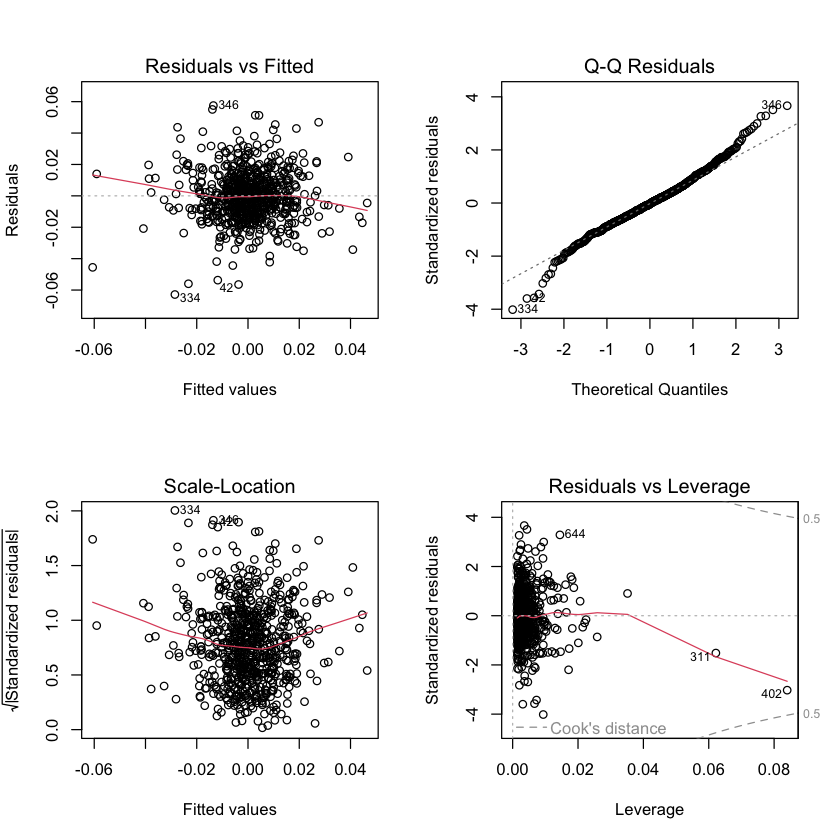

In [8]:
# Load data
df <- read.delim("/Users/manu/Downloads/w_logret_3automanu.txt",
                 header = TRUE,
                 stringsAsFactors = FALSE)

# Convert Date column
df$Date <- as.Date(df$Date, format = "%m/%d/%Y")

# Check data
head(df)
str(df)
summary(df)

# Fit multiple linear regression
fit <- lm(GM ~ Toyota + Ford, data = df)

# Main regression results
summary(fit)

# 95% confidence intervals
confint(fit)

# Standard diagnostic plots
par(mfrow = c(2, 2))
plot(fit)
par(mfrow = c(1, 1))

# Residuals
res <- residuals(fit)

# Residual summary
summary(res)

# Normality test
shapiro.test(res)

# Durbin-Watson statistic for autocorrelation
dw <- sum(diff(res)^2) / sum(res^2)
dw

# Breusch-Pagan test for heteroskedasticity
e2 <- res^2
bp_aux <- lm(e2 ~ Toyota + Ford, data = df)

bp_stat <- nrow(df) * summary(bp_aux)$r.squared
bp_p_value <- pchisq(bp_stat, df = 2, lower.tail = FALSE)

c(
  BP_statistic = bp_stat,
  df = 2,
  p_value = bp_p_value
)

# VIF for multicollinearity
r2_toyota <- summary(lm(Toyota ~ Ford, data = df))$r.squared
r2_ford <- summary(lm(Ford ~ Toyota, data = df))$r.squared

vif_toyota <- 1 / (1 - r2_toyota)
vif_ford <- 1 / (1 - r2_ford)

c(
  Toyota_VIF = vif_toyota,
  Ford_VIF = vif_ford
)

# Influence diagnostics
hat <- hatvalues(fit)
cooks <- cooks.distance(fit)
std_res <- rstandard(fit)

n <- nobs(fit)
p <- length(coef(fit))

high_leverage_threshold <- 2 * p / n
cooks_threshold <- 4 / n

c(
  high_leverage_threshold = high_leverage_threshold,
  cooks_threshold = cooks_threshold,
  large_standardized_residuals = sum(abs(std_res) > 3),
  high_leverage_points = sum(hat > high_leverage_threshold),
  influential_points = sum(cooks > cooks_threshold)
)

# Top 10 influential observations
top <- order(cooks, decreasing = TRUE)[1:10]

data.frame(
  row = top,
  Date = df$Date[top],
  GM = df$GM[top],
  Toyota = df$Toyota[top],
  Ford = df$Ford[top],
  std_residual = std_res[top],
  leverage = hat[top],
  cooks_distance = cooks[top]
)

# Banker's 

The regression suggests that GM’s weekly returns move much more closely with Ford than with Toyota. Ford’s coefficient is large and highly statistically significant, meaning Ford appears to be the stronger peer indicator for GM in this sample.
Toyota’s coefficient is positive but not statistically significant, so it should not be treated as a reliable driver of GM returns in this model. The model explains about 38% of the variation in GM’s weekly returns, which is useful but leaves substantial company-specific and market-wide risk unexplained.
For decision-making, this model may help with peer comparison, hedging intuition, or stress testing GM against Ford movements. However, it should not be used alone for trading, lending, or valuation decisions because the residuals show non-normal tails and some influential observations, meaning extreme weeks can materially affect the relationship.

# Prompts

Give a short, readable summary that a banker may use when making financial decisions related to the model that you gave

Could you fit GM ~ Toyota + Ford to R and then run standard diagnostics for linear regression on the output?